In [55]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## 1: Load image paths and labels from TrainImages.txt and TestImages.txt

In [57]:
rootDir = '/kaggle/input/indoor-scenes-cvpr-2019/indoorCVPR_09/Images'

allData = []
for label in sorted(os.listdir(rootDir)):
    labelDir = os.path.join(rootDir, label)
    if os.path.isdir(labelDir):
        for file in os.listdir(labelDir):
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                imgPath = os.path.join(labelDir, file)
                allData.append((imgPath, label))

# 80-10-10 stratified split
trainData, tempData = train_test_split(
    allData, test_size=0.2, stratify=[label for _, label in allData], random_state=42
)
valData, testData = train_test_split(
    tempData, test_size=0.5, stratify=[label for _, label in tempData], random_state=42
)

labelNames = sorted(set([label for _, label in allData]))
labelToIndex = {label: idx for idx, label in enumerate(labelNames)}
classNames = labelNames

print(f"Loaded: Train = {len(trainData)}, Val = {len(valData)}, Test = {len(testData)}")


Loaded: Train = 12496, Val = 1562, Test = 1562


## 2: Create custom PyTorch Dataset using parsed image-label pairs


In [58]:

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
trainTransform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomAffine(degrees=15, shear=10),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])





class SceneDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        imgPath, label = self.data[idx]
        image = Image.open(imgPath).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, labelToIndex[label]



Class Distribution in Train Set:
airport_inside      : 486
artstudio           : 112
auditorium          : 141
bakery              : 324
bar                 : 483
bathroom            : 158
bedroom             : 530
bookstore           : 304
bowling             : 170
buffet              : 89
casino              : 412
children_room       : 90
church_inside       : 144
classroom           : 90
cloister            : 96
closet              : 108
clothingstore       : 85
computerroom        : 91
concert_hall        : 82
corridor            : 277
deli                : 206
dentaloffice        : 105
dining_room         : 219
elevator            : 81
fastfood_restaurant : 93
florist             : 82
gameroom            : 102
garage              : 82
greenhouse          : 81
grocerystore        : 170
gym                 : 185
hairsalon           : 191
hospitalroom        : 81
inside_bus          : 82
inside_subway       : 366
jewelleryshop       : 126
kindergarden        : 102
kitchen           

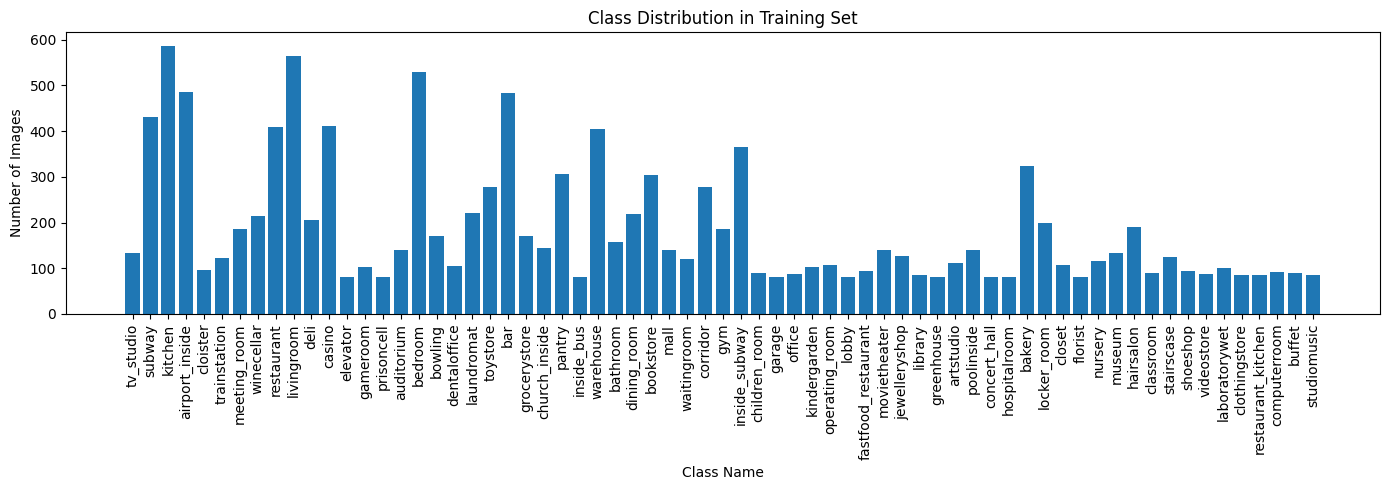

In [59]:
from collections import Counter
import matplotlib.pyplot as plt

# Count training samples per class
trainLabels = [label for _, label in trainData]
labelCounts = Counter(trainLabels)

# Print counts
print("\nClass Distribution in Train Set:")
for cls in sorted(labelCounts):
    print(f"{cls:20s}: {labelCounts[cls]}")

# Optional: plot class distribution
plt.figure(figsize=(14, 5))
plt.bar(labelCounts.keys(), labelCounts.values())
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set")
plt.xlabel("Class Name")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


## 3: Create DataLoaders for training, validation, and testing


In [60]:
batchSize = 64

trainDataset = SceneDataset(trainData, trainTransform)
valDataset = SceneDataset(valData, transform)
testDataset = SceneDataset(testData, transform)

trainLoader = DataLoader(trainDataset, batch_size=batchSize, shuffle=True)
valLoader = DataLoader(valDataset, batch_size=batchSize, shuffle=False)
testLoader = DataLoader(testDataset, batch_size=batchSize, shuffle=False)

classNames = labelNames


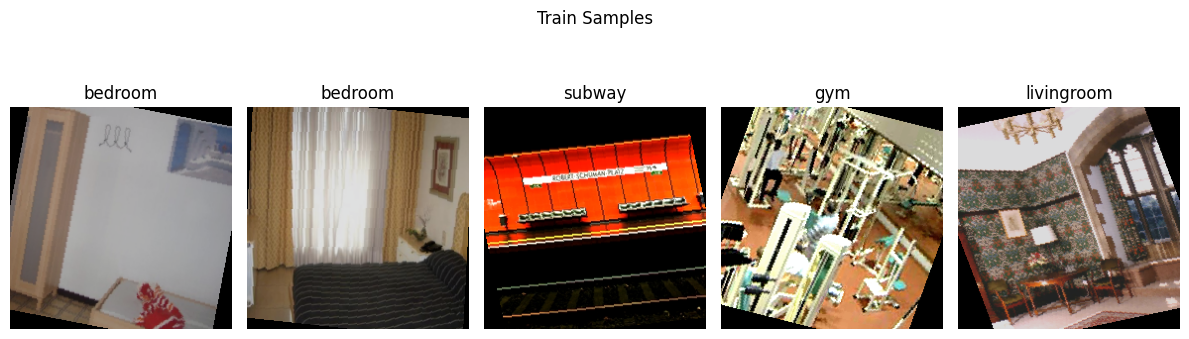

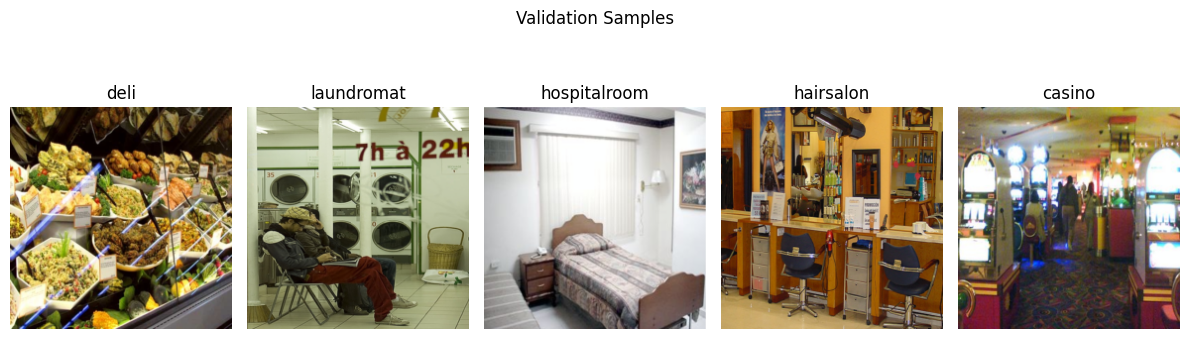

In [61]:

def showSamples(dataLoader, classNames, title="Sample Images"):
    images, labels = next(iter(dataLoader))
    plt.figure(figsize=(12, 4))
    for i in range(5):
        img = images[i].permute(1, 2, 0).numpy()  # Convert CHW → HWC
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # Unnormalize
        img = np.clip(img, 0, 1)
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.title(classNames[labels[i].item()])
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

showSamples(trainLoader, classNames, title="Train Samples")
showSamples(valLoader, classNames, title="Validation Samples")


## 4: Define the custom multi-branch CNN using bottleneck Inception block


In [62]:
import torch
import torch.nn as nn

# Dense Layer
class DenseLayer(nn.Module):
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, growth_rate, kernel_size=3, padding=1, bias=False)

    def forward(self, x):
        out = self.conv(self.relu(self.bn(x)))
        return torch.cat([x, out], 1)  # Dense connection

# Dense Block
class DenseBlock(nn.Module):
    def __init__(self, num_layers, in_channels, growth_rate):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

# Transition Layer
class TransitionLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.layer = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.AvgPool2d(2)
        )

    def forward(self, x):
        return self.layer(x)

#Full DenseNet
class DenseNetLikeSceneClassifier(nn.Module):
    def __init__(self, growth_rate=32, block_layers=[4, 6, 8], num_classes=67):
        super(DenseNetLikeSceneClassifier, self).__init__()

        # Initial Conv Layer
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),  # Conv
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1)  # Pool
        )

        # Dense Blocks + Transitions
        self.features = nn.Sequential()
        num_channels = 64
        for i, num_layers in enumerate(block_layers):
            block = DenseBlock(num_layers, num_channels, growth_rate)
            self.features.add_module(f'denseblock{i+1}', block)
            num_channels = num_channels + num_layers * growth_rate
            if i != len(block_layers) - 1:  # no transition after last block
                trans = TransitionLayer(num_channels, num_channels // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_channels = num_channels // 2

        # Final batch norm
        self.bn_final = nn.BatchNorm2d(num_channels)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(num_channels, num_classes)
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.bn_final(x)
        x = self.classifier(x)
        return x


In [64]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DenseNetLikeSceneClassifier(
    growth_rate=32,
    block_layers=[4, 6, 8],
    num_classes=67
).to(device)




summary(model, input_size=(1, 3, 224, 224))


Layer (type:depth-idx)                        Output Shape              Param #
DenseNetLikeSceneClassifier                   [1, 67]                   --
├─Sequential: 1-1                             [1, 64, 56, 56]           --
│    └─Conv2d: 2-1                            [1, 64, 112, 112]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 112, 112]         128
│    └─ReLU: 2-3                              [1, 64, 112, 112]         --
│    └─MaxPool2d: 2-4                         [1, 64, 56, 56]           --
├─Sequential: 1-2                             [1, 400, 14, 14]          --
│    └─DenseBlock: 2-5                        [1, 192, 56, 56]          --
│    │    └─Sequential: 3-1                   [1, 192, 56, 56]          129,920
│    └─TransitionLayer: 2-6                   [1, 96, 28, 28]           --
│    │    └─Sequential: 3-2                   [1, 96, 28, 28]           18,816
│    └─DenseBlock: 2-7                        [1, 288, 28, 28]          --
│    │ 

In [68]:
def hook_fn(module, input, output):
    print("Intermediate feature shape before classifier:", output.shape)

# Register the hook on bn_final
handle = model.bn_final.register_forward_hook(hook_fn)

# Run dummy input through full model
with torch.no_grad():
    dummy = torch.randn(1, 3, 224, 224).to(device)
    _ = model(dummy)

# Clean up
handle.remove()

Intermediate feature shape before classifier: torch.Size([1, 400, 14, 14])


5: Setup device, loss function, optimizer, LR scheduler, and early stopping

In [69]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

trainEncodedLabels = [labelToIndex[label] for _, label in trainData]  # Or however you store them

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(trainEncodedLabels),
    y=trainEncodedLabels
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)


In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DenseNetLikeSceneClassifier(
    growth_rate=32,
    block_layers=[6, 12, 24, 16],
    num_classes=67
).to(device)

# Use weighted cross entropy loss
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1  # Keep this to help with noisy labels
)

# Optimizer and scheduler
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=5e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100)
earlyStopPatience = 15
batchSize = 64


In [49]:
import time

def trainModel(model, trainLoader, valLoader, criterion, optimizer, scheduler, epochs=50, earlyStopPatience=5):
    bestValAcc = 0
    patienceCounter = 0

    trainAccList, valAccList, trainLossList, valLossList = [], [], [], []

    for epoch in range(epochs):
        start_time = time.time()

        model.train()
        totalTrainLoss, correctTrain, totalTrain = 0, 0, 0

        for images, labels in trainLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            totalTrainLoss += loss.item()
            _, preds = outputs.max(1)
            correctTrain += (preds == labels).sum().item()
            totalTrain += labels.size(0)

        trainAcc = correctTrain / totalTrain
        trainLoss = totalTrainLoss / len(trainLoader)

        valLoss, valAcc = evaluateModel(model, valLoader, criterion)

        trainAccList.append(trainAcc)
        valAccList.append(valAcc)
        trainLossList.append(trainLoss)
        valLossList.append(valLoss)

        scheduler.step()

        elapsed_time = time.time() - start_time
        print(f"Current LR: {scheduler.get_last_lr()[0]:.6f}")
        print(f"Epoch {epoch+1:02d} | Train Acc: {trainAcc:.4f} | Val Acc: {valAcc:.4f} | "
              f"Train Loss: {trainLoss:.4f} | Val Loss: {valLoss:.4f} | Time: {elapsed_time:.2f}s")

        if valAcc > bestValAcc:
            bestValAcc = valAcc
            patienceCounter = 0
            torch.save(model.state_dict(), "bestModel.pth")
        else:
            patienceCounter += 1
            if patienceCounter >= earlyStopPatience:
                print("Early stopping triggered.")
                break

    return trainAccList, valAccList, trainLossList, valLossList


In [71]:

def evaluateModel(model, dataLoader, criterion):
    model.eval()
    totalLoss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in dataLoader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            totalLoss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avgLoss = totalLoss / len(dataLoader)
    accuracy = correct / total
    return avgLoss, accuracy

In [52]:
trainAccList, valAccList, trainLossList, valLossList = trainModel(
    model, trainLoader, valLoader, criterion, optimizer, scheduler,
    epochs=70, earlyStopPatience=earlyStopPatience
)


Current LR: 0.000200
Epoch 01 | Train Acc: 0.0677 | Val Acc: 0.1005 | Train Loss: 4.1082 | Val Loss: 3.9337 | Time: 186.50s
Current LR: 0.000200
Epoch 02 | Train Acc: 0.0935 | Val Acc: 0.1319 | Train Loss: 3.9427 | Val Loss: 3.7982 | Time: 186.74s
Current LR: 0.000200
Epoch 03 | Train Acc: 0.1168 | Val Acc: 0.1088 | Train Loss: 3.8300 | Val Loss: 3.7841 | Time: 186.81s
Current LR: 0.000199
Epoch 04 | Train Acc: 0.1333 | Val Acc: 0.1633 | Train Loss: 3.7359 | Val Loss: 3.5431 | Time: 186.70s
Current LR: 0.000199
Epoch 05 | Train Acc: 0.1589 | Val Acc: 0.1805 | Train Loss: 3.6468 | Val Loss: 3.5720 | Time: 185.39s
Current LR: 0.000198
Epoch 06 | Train Acc: 0.1737 | Val Acc: 0.1882 | Train Loss: 3.5709 | Val Loss: 3.4951 | Time: 185.58s
Current LR: 0.000198
Epoch 07 | Train Acc: 0.1961 | Val Acc: 0.1914 | Train Loss: 3.4995 | Val Loss: 3.4359 | Time: 185.95s
Current LR: 0.000197
Epoch 08 | Train Acc: 0.2157 | Val Acc: 0.2714 | Train Loss: 3.4245 | Val Loss: 3.2598 | Time: 187.01s
Current 

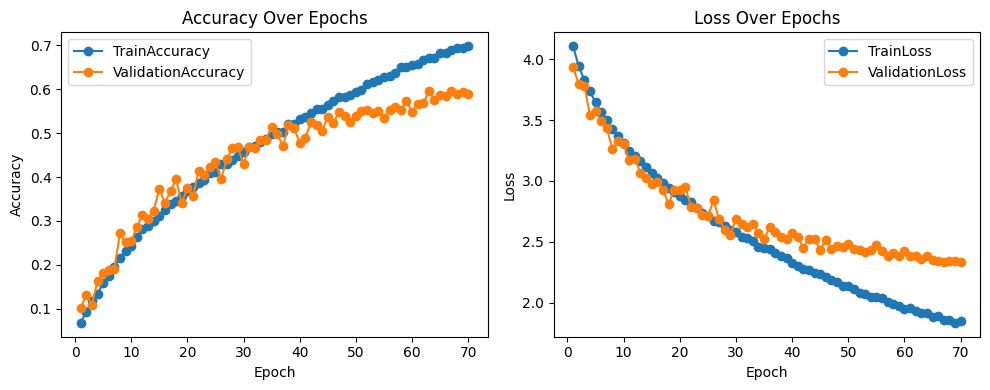

In [53]:
import matplotlib.pyplot as plt

def plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList):
    Epochs = range(1, len(trainAccList) + 1)

    # Accuracy Plot
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(Epochs, trainAccList, label='TrainAccuracy', marker='o')
    plt.plot(Epochs, valAccList, label='ValidationAccuracy', marker='o')
    plt.title('Accuracy Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(Epochs, trainLossList, label='TrainLoss', marker='o')
    plt.plot(Epochs, valLossList, label='ValidationLoss', marker='o')
    plt.title('Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plotAccuracyLoss(trainAccList, valAccList, trainLossList, valLossList)


In [72]:
model.load_state_dict(torch.load("/kaggle/input/dense-model/bestModelDenseNetCustom.pth"))
testLoss, testAcc = evaluateModel(model, testLoader, criterion)
print(f"Test Accuracy: {testAcc*100:.4f} Test Loss: {testLoss:.4f}")

Test Accuracy: 59.0269 Test Loss: 2.2868


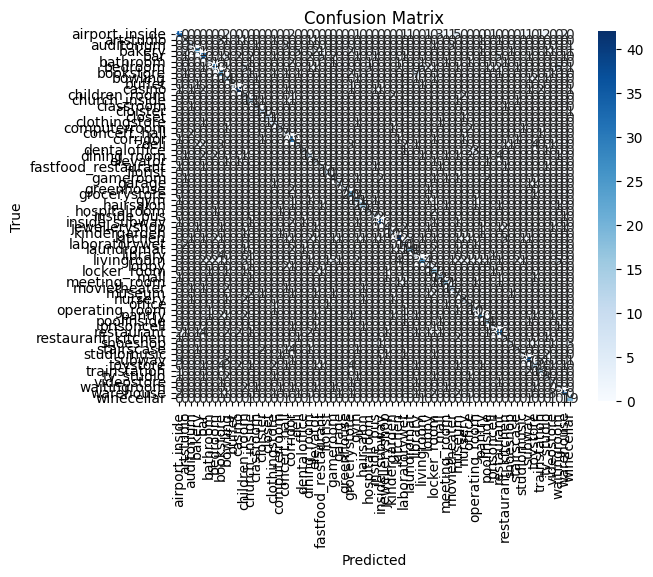

                     precision    recall  f1-score   support

     airport_inside       0.61      0.57      0.59        61
          artstudio       0.25      0.21      0.23        14
         auditorium       0.53      0.47      0.50        17
             bakery       0.79      0.56      0.66        41
                bar       0.62      0.52      0.57        61
           bathroom       0.64      0.45      0.53        20
            bedroom       0.79      0.45      0.58        66
          bookstore       0.50      0.58      0.54        38
            bowling       0.38      0.64      0.47        22
             buffet       1.00      0.73      0.84        11
             casino       0.83      0.76      0.80        51
      children_room       0.24      0.55      0.33        11
      church_inside       0.48      0.72      0.58        18
          classroom       0.75      0.82      0.78        11
           cloister       0.69      0.92      0.79        12
             closet    

In [73]:
allLabels, allPreds = [], []
model.eval()
with torch.no_grad():
    for images, labels in testLoader:
        images = images.to(device)
        outputs = model(images)
        _, preds = outputs.max(1)
        allLabels.extend(labels.cpu().numpy())
        allPreds.extend(preds.cpu().numpy())

cm = confusion_matrix(allLabels, allPreds)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classNames, yticklabels=classNames, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
report_dict = classification_report(allLabels, allPreds, target_names=classNames, output_dict=True)
print(classification_report(allLabels, allPreds, target_names=classNames))


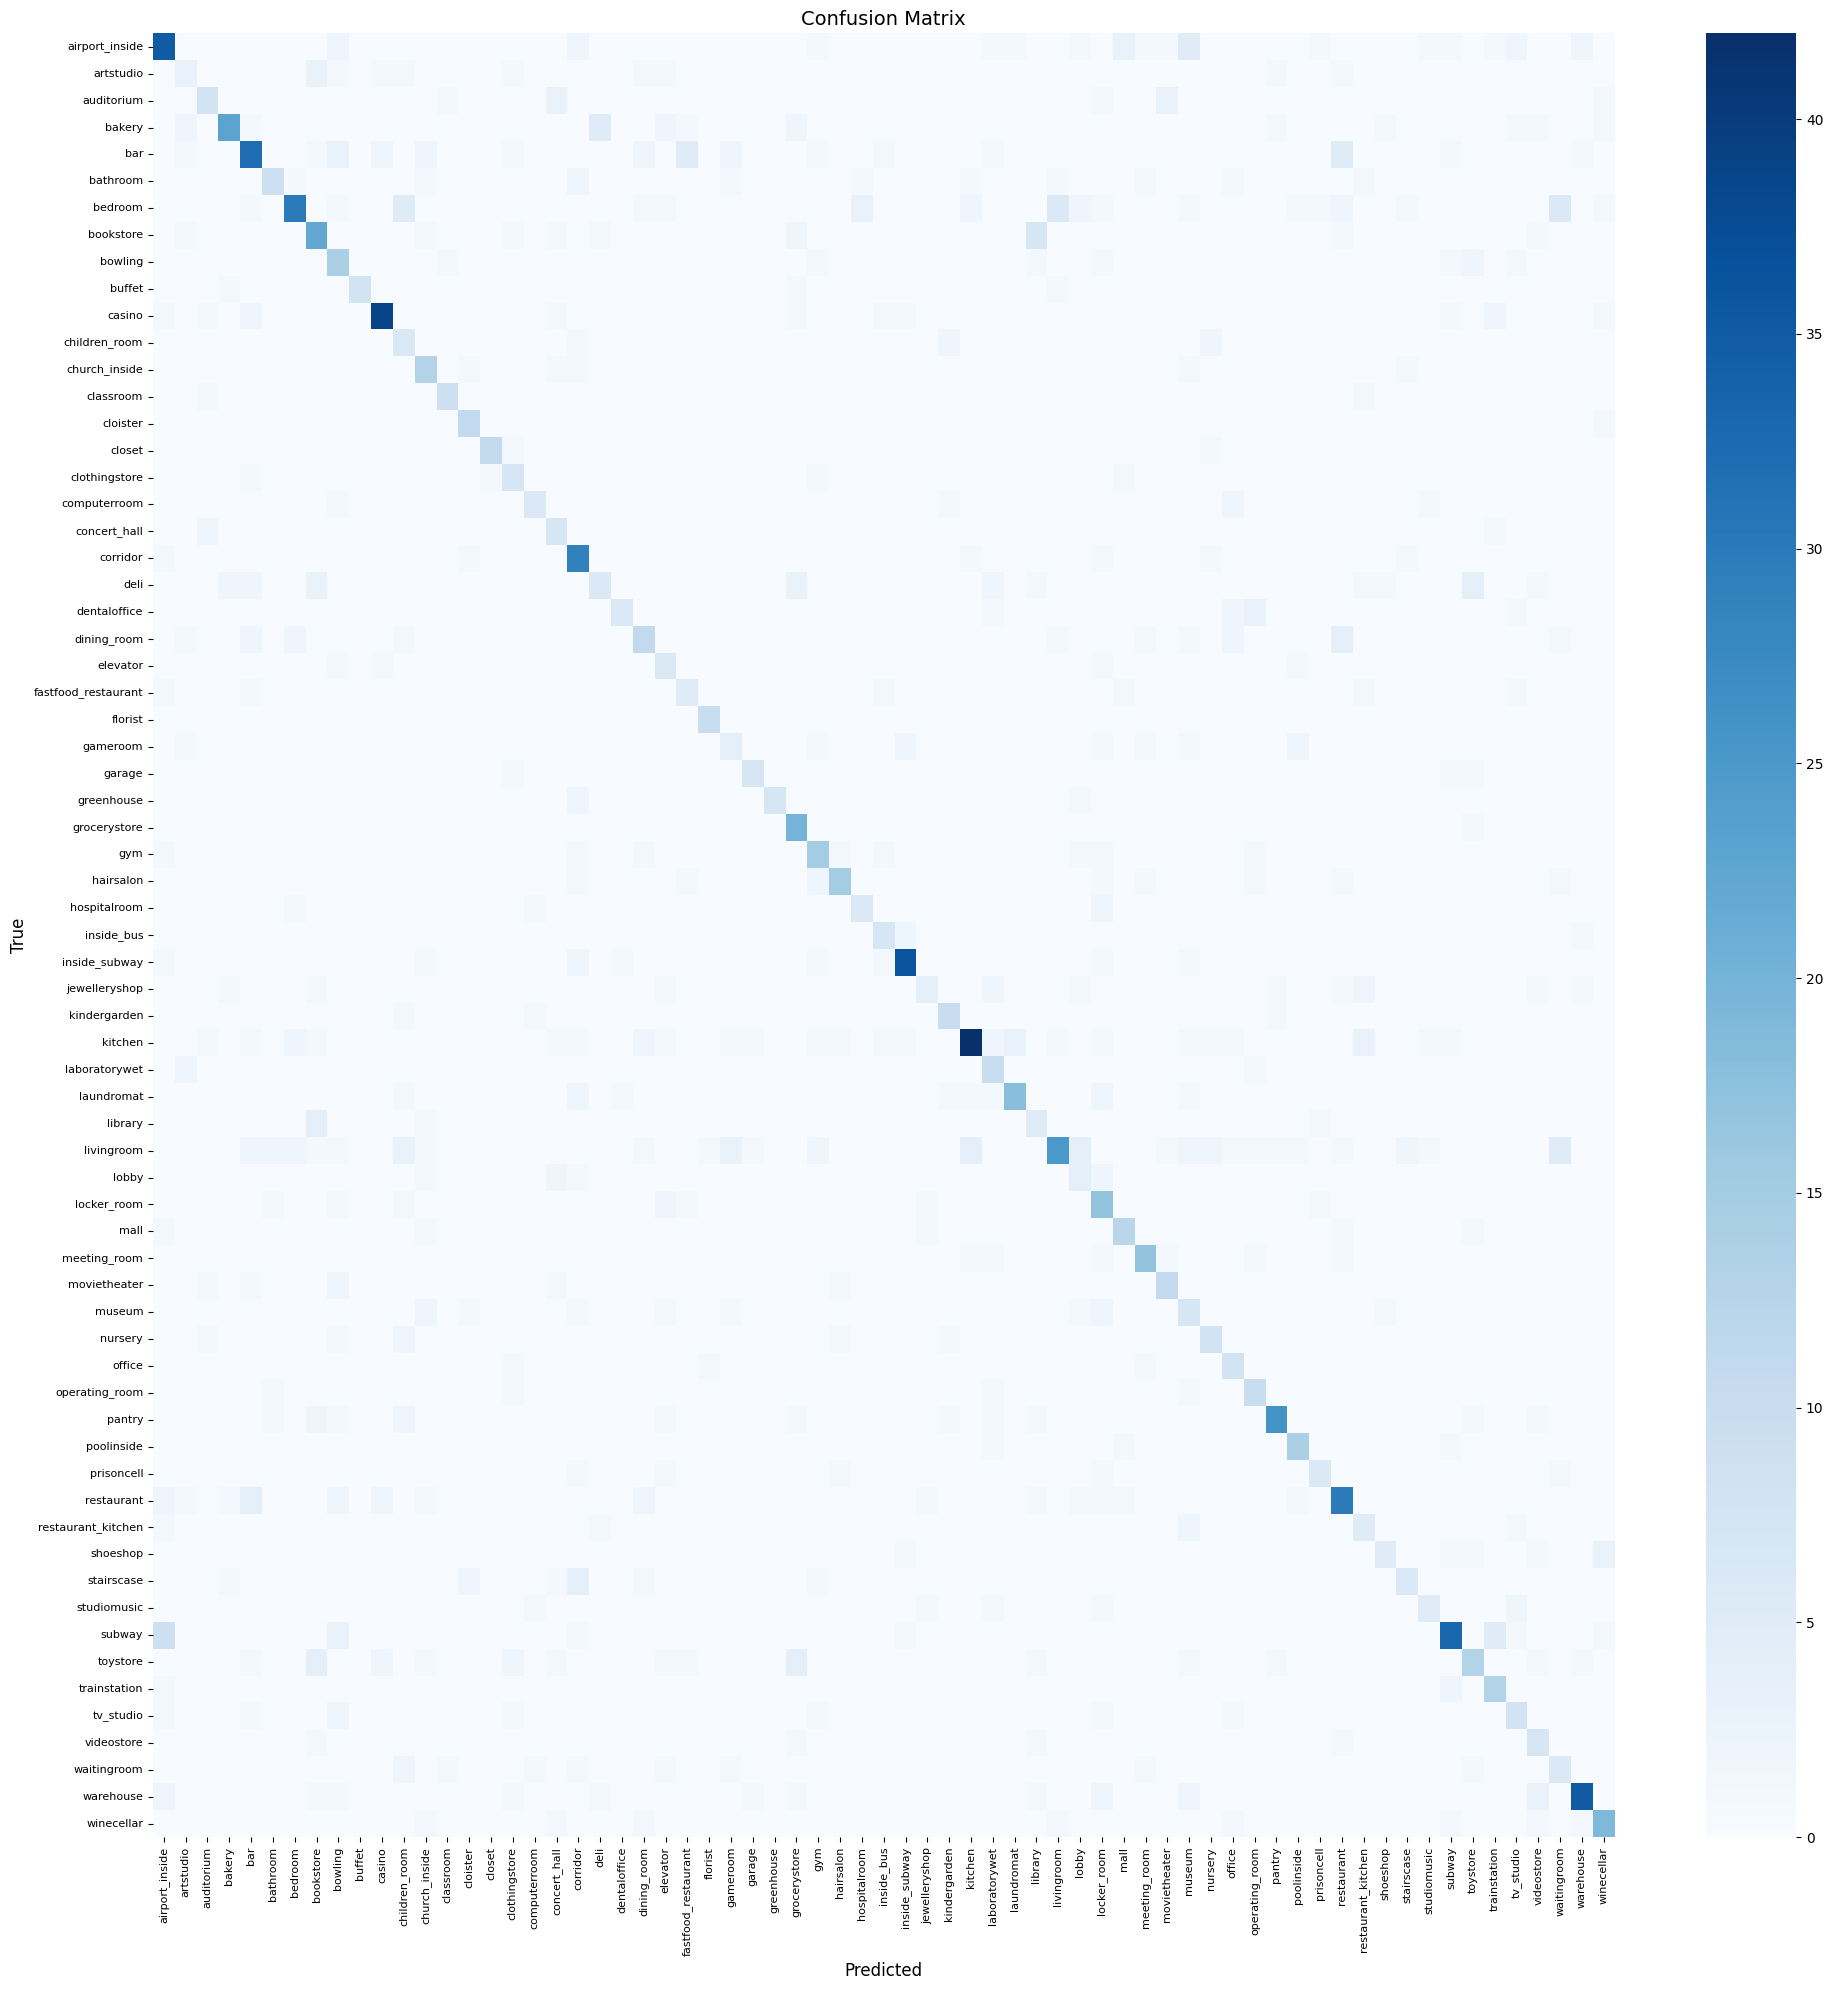

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(allLabels, allPreds)

# Set figure size to avoid label overlap
plt.figure(figsize=(20, 20))

# Plot the heatmap with no annotations to keep it clean
sns.heatmap(cm, cmap='Blues', xticklabels=classNames, yticklabels=classNames)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.xlabel("Predicted", fontsize=12)
plt.ylabel("True", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()


In [75]:
import pandas as pd

df_report = pd.DataFrame(report_dict).transpose()

# Round for readability (optional)
df_report = df_report.round(2)

# Now this will work
low_f1 = df_report[df_report['f1-score'] < 0.45]
print("Low performing classes:\n", low_f1)


Low performing classes:
                      precision  recall  f1-score  support
artstudio                 0.25    0.21      0.23     14.0
children_room             0.24    0.55      0.33     11.0
deli                      0.43    0.23      0.30     26.0
dining_room               0.48    0.41      0.44     27.0
elevator                  0.32    0.60      0.41     10.0
fastfood_restaurant       0.36    0.45      0.40     11.0
gameroom                  0.31    0.31      0.31     13.0
jewelleryshop             0.50    0.25      0.33     16.0
library                   0.26    0.45      0.33     11.0
lobby                     0.25    0.40      0.31     10.0
museum                    0.26    0.41      0.32     17.0
restaurant_kitchen        0.36    0.50      0.42     10.0
stairscase                0.55    0.38      0.44     16.0
toystore                  0.52    0.37      0.43     35.0
waitingroom               0.30    0.40      0.34     15.0


In [77]:
from collections import Counter
import pandas as pd
from sklearn.metrics import classification_report

# Count class distribution in the training set
labelCounts = Counter([label for _, label in trainData])

# Get classification report as dict
report_dict = classification_report(allLabels, allPreds, target_names=classNames, output_dict=True)

# Create dataframe from report and clean it
df_report = pd.DataFrame(report_dict).transpose().round(2)

# Filter: Remove 'accuracy', 'macro avg', 'weighted avg'
df_report = df_report.loc[classNames]

# Add train set class count
df_report['train_count'] = df_report.index.map(lambda cls: labelCounts.get(cls, 0))

# Filter low-performing classes based on F1-score threshold
low_f1_df = df_report[df_report['f1-score'] < 0.45]

# Print combined table
print("\nLow Performing Classes (F1-score < 0.45):")
print(low_f1_df[['train_count', 'f1-score']])



Low Performing Classes (F1-score < 0.45):
                     train_count  f1-score
artstudio                    112      0.23
children_room                 90      0.33
deli                         206      0.30
dining_room                  219      0.44
elevator                      81      0.41
fastfood_restaurant           93      0.40
gameroom                     102      0.31
jewelleryshop                126      0.33
library                       86      0.33
lobby                         81      0.31
museum                       134      0.32
restaurant_kitchen            86      0.42
stairscase                   124      0.44
toystore                     278      0.43
waitingroom                  121      0.34


In [98]:
num_low_f1_classes = len(low_f1_df)
print(num_low_f1_classes)
low_f1_classes_names = low_f1_df.index.tolist()

print(low_f1_classes_names)

15
['artstudio', 'children_room', 'deli', 'dining_room', 'elevator', 'fastfood_restaurant', 'gameroom', 'jewelleryshop', 'library', 'lobby', 'museum', 'restaurant_kitchen', 'stairscase', 'toystore', 'waitingroom']


In [99]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from copy import deepcopy

# --------------------- Configuration ---------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# low_f1_classes = ['artstudio', 'deli', 'elevator', 'library', 'lobby', 'museum']
low_f1_classes = low_f1_classes_names
# --------------------- Transforms ---------------------
strong_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(), transforms.RandomRotation(25)], p=0.5),
    transforms.ToTensor()
])

default_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# --------------------- Dataset Class ---------------------
class CustomSceneDataset(Dataset):
    def __init__(self, data, label_map, transform_map):
        self.data = data
        self.label_map = label_map
        self.transform_map = transform_map

    def __getitem__(self, index):
        img_path, label_name = self.data[index]
        image = Image.open(img_path).convert("RGB")
        transform = self.transform_map.get(label_name, default_transform)
        image = transform(image)
        label = self.label_map[label_name]
        return image, label

    def __len__(self):
        return len(self.data)

# --------------------- Prepare Data ---------------------
# Filter for low-F1 classes
filtered_train = [(img, label) for img, label in trainData if label in low_f1_classes]
filtered_val = [(img, label) for img, label in valData if label in low_f1_classes]

# Create label map
fine_label_names = sorted(set(label for _, label in filtered_train))
fine_label_to_idx = {label: idx for idx, label in enumerate(fine_label_names)}
idx_to_fine_label = {v: k for k, v in fine_label_to_idx.items()}
num_low_f1_classes = len(fine_label_names)

# Create transform map
transform_map = {cls: strong_transform for cls in low_f1_classes}

# Create datasets
train_ds = CustomSceneDataset(filtered_train, fine_label_to_idx, transform_map)
val_ds = CustomSceneDataset(filtered_val, fine_label_to_idx, transform_map)

# --------------------- Weighted Sampler ---------------------
class_counts = {cls: 0 for cls in fine_label_names}
for _, label in filtered_train:
    class_counts[label] += 1

sample_weights = [1.0 / class_counts[label] for _, label in filtered_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# --------------------- Dataloaders ---------------------
train_loader = DataLoader(train_ds, batch_size=32, sampler=sampler, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

# --------------------- Finetune Model ---------------------
finetune_model = deepcopy(model)  # Assuming `model` is your pretrained DenseNet-like model

# Replace classifier head: assume final feature map is [B, 400, 14, 14]
finetune_model.classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),          # [B, 400, 14, 14] → [B, 400, 1, 1]
    nn.Flatten(),                          # [B, 400, 1, 1] → [B, 400]
    nn.Linear(1024, num_low_f1_classes)     # Final layer
)

finetune_model = finetune_model.to(device)

# --------------------- Loss & Optimizer ---------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(finetune_model.parameters(), lr=1e-4)

# --------------------- Training Loop ---------------------
def train_finetune_model(model, train_loader, val_loader, num_epochs, device):
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{num_epochs}]")

        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Metrics
            running_loss += loss.item() * imgs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100. * correct / total)

        print(f"\nEpoch [{epoch+1}] - Loss: {running_loss/total:.4f}, Acc: {100.*correct/total:.2f}%")

        evaluate_finetune_model(model, val_loader, device)

# --------------------- Evaluation ---------------------
def evaluate_finetune_model(model, val_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()
    acc = 100. * correct / total
    print(f"Validation Accuracy: {acc:.2f}%")
    model.train()

# --------------------- Start Training ---------------------
train_finetune_model(finetune_model, train_loader, val_loader, num_epochs=20, device=device)


Epoch [1/20]: 100%|██████████| 61/61 [00:20<00:00,  2.94it/s, acc=53.8, loss=1.07]


Epoch [1] - Loss: 1.7151, Acc: 53.84%


Validation Accuracy: 45.83%


Epoch [2/20]: 100%|██████████| 61/61 [00:20<00:00,  2.96it/s, acc=70.8, loss=0.835]


Epoch [2] - Loss: 1.0555, Acc: 70.76%


...


Epoch [19] - Loss: 0.4941, Acc: 85.25%


Validation Accuracy: 52.08%


Epoch [20/20]: 100%|██████████| 61/61 [00:19<00:00,  3.06it/s, acc=86.3, loss=0.299]


Epoch [20] - Loss: 0.4649, Acc: 86.28%


Validation Accuracy: 53.33%


In [100]:
from sklearn.metrics import classification_report
import pandas as pd

# Step 1: Evaluate fine-tuned model on validation set
finetune_model.eval()
y_true_new, y_pred_new = [], []

with torch.no_grad():
    for imgs, labels in val_loader:  # use the same val_loader used during fine-tuning
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = finetune_model(imgs)
        _, preds = torch.max(outputs, 1)
        y_true_new.extend(labels.cpu().numpy())
        y_pred_new.extend(preds.cpu().numpy())

# Step 2: Generate new classification report
target_names = list(fine_label_to_idx.keys())  # low-F1 class names
df_report_after = classification_report(
    y_true_new, y_pred_new, target_names=target_names, output_dict=True
)
df_report_after = pd.DataFrame(df_report_after).transpose()

# Step 3: Compare before and after (F1-score only)
f1_before = df_report.loc[target_names, "f1-score"]
f1_after = df_report_after.loc[target_names, "f1-score"]
comparison_df = pd.DataFrame({
    "F1-Before": f1_before,
    "F1-After": f1_after,
    "Delta": f1_after - f1_before
})

print("\n F1-score Comparison (Before vs After Fine-tuning):")
print(comparison_df)



 F1-score Comparison (Before vs After Fine-tuning):
                     F1-Before  F1-After     Delta
artstudio                 0.23  0.214286 -0.015714
children_room             0.33  0.210526 -0.119474
deli                      0.30  0.576923  0.276923
dining_room               0.44  0.577778  0.137778
elevator                  0.41  0.416667  0.006667
fastfood_restaurant       0.40  0.272727 -0.127273
gameroom                  0.31  0.500000  0.190000
jewelleryshop             0.33  0.555556  0.225556
library                   0.33  0.588235  0.258235
lobby                     0.31  0.375000  0.065000
museum                    0.32  0.413793  0.093793
restaurant_kitchen        0.42  0.444444  0.024444
stairscase                0.44  0.555556  0.115556
toystore                  0.43  0.644068  0.214068
waitingroom               0.34  0.500000  0.160000


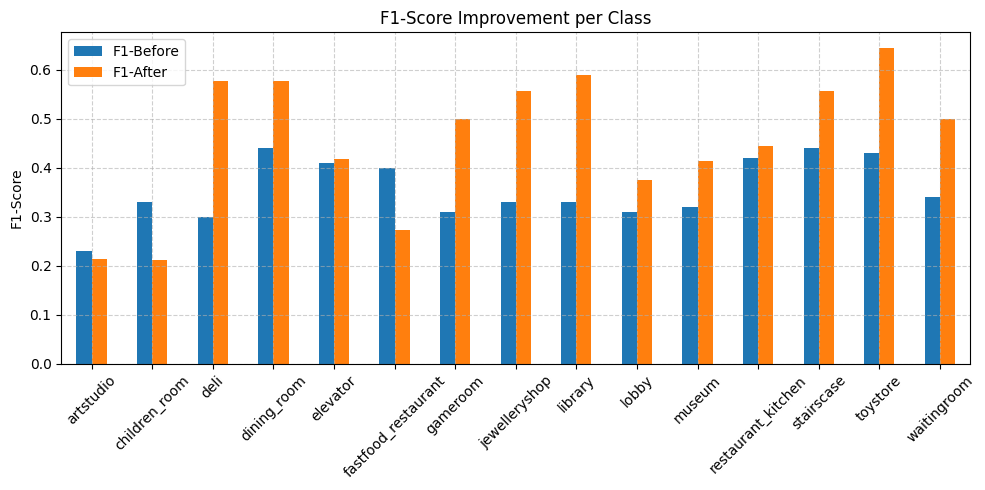

In [101]:
import matplotlib.pyplot as plt

comparison_df[["F1-Before", "F1-After"]].plot(kind="bar", figsize=(10, 5))
plt.title("F1-Score Improvement per Class")
plt.ylabel("F1-Score")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [113]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

threshold = 0.5
still_low_df = comparison_df[comparison_df["F1-After"] < threshold]
# still_low_classes = list(still_low_df["Class"])
still_low_classes = list(still_low_df.index)


filtered_train_2 = [(img, label) for img, label in trainData if label in still_low_classes]
filtered_val_2 = [(img, label) for img, label in valData if label in still_low_classes]

fine2_label_names = sorted(set(label for _, label in filtered_train_2))
fine2_label_to_idx = {label: idx for idx, label in enumerate(fine2_label_names)}
idx_to_fine2_label = {v: k for k, v in fine2_label_to_idx.items()}

class CustomSceneDataset(Dataset):
    def __init__(self, data, label_map, transform):
        self.data = data
        self.label_map = label_map
        self.transform = transform

    def __getitem__(self, idx):
        img_path, label = self.data[idx]
        image = Image.open(img_path).convert("RGB")
        image = self.transform(image)
        return image, self.label_map[label]

    def __len__(self):
        return len(self.data)

strong_aug = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomApply([transforms.ColorJitter(), transforms.RandomRotation(25)], p=0.5),
    transforms.ToTensor()
])
val_aug = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor()])

# Step 5: Datasets & Loaders
train_ds2 = CustomSceneDataset(filtered_train_2, fine2_label_to_idx, strong_aug)
val_ds2 = CustomSceneDataset(filtered_val_2, fine2_label_to_idx, val_aug)

train_loader2 = DataLoader(train_ds2, batch_size=32, shuffle=True, num_workers=2)
val_loader2 = DataLoader(val_ds2, batch_size=32, shuffle=False, num_workers=2)

# Step 6: Adjust model classifier
boost_model = deepcopy(finetune_model)
boost_model.classifier = nn.Sequential(
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten(),
    nn.Linear(1024, len(fine2_label_names))
)
boost_model = boost_model.to(device)

# Step 7: Training Code
def train_boost(model, train_loader, val_loader, epochs=5, lr=1e-4):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    model.train()
    for epoch in range(epochs):
        total, correct, running_loss = 0, 0, 0.0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")
        for imgs, labels in loop:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            total += labels.size(0)
            correct += preds.eq(labels).sum().item()

            loop.set_postfix(loss=loss.item(), acc=100.*correct/total)
        print(f"Epoch {epoch+1} - Loss: {running_loss/total:.4f}, Acc: {100.*correct/total:.2f}%")

    evaluate_boost(model, val_loader)

def evaluate_boost(model, val_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
    print(f"Boosted Validation Accuracy: {100.*correct/total:.2f}%")
    model.train()

# Step 8: Start second-stage boosting
train_boost(boost_model, train_loader2, val_loader2, epochs=5)


Epoch [1/5]: 100%|██████████| 22/22 [00:06<00:00,  3.16it/s, acc=65.1, loss=1.17] 


Epoch 1 - Loss: 1.1902, Acc: 65.14%


Epoch [2/5]: 100%|██████████| 22/22 [00:07<00:00,  3.05it/s, acc=83.2, loss=0.52] 


Epoch 2 - Loss: 0.5848, Acc: 83.16%


Epoch [3/5]: 100%|██████████| 22/22 [00:07<00:00,  2.99it/s, acc=86.1, loss=0.369]


...

Epoch [4/5]: 100%|██████████| 22/22 [00:07<00:00,  2.89it/s, acc=88.6, loss=0.632]


Epoch 4 - Loss: 0.4103, Acc: 88.63%


Epoch [5/5]: 100%|██████████| 22/22 [00:07<00:00,  2.83it/s, acc=89.5, loss=0.984]

Epoch 5 - Loss: 0.3786, Acc: 89.51%


Boosted Validation Accuracy: 62.35%


In [114]:
from sklearn.metrics import classification_report

def get_f1_report(model, data_loader, label_map):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in data_loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    inv_label_map = {v: k for k, v in label_map.items()}
    return classification_report(all_labels, all_preds, target_names=[inv_label_map[i] for i in sorted(inv_label_map)])

print(get_f1_report(boost_model, val_loader2, fine2_label_to_idx))


                     precision    recall  f1-score   support

          artstudio       0.71      0.36      0.48        14
      children_room       0.73      0.73      0.73        11
           elevator       0.58      0.70      0.64        10
fastfood_restaurant       0.48      1.00      0.65        12
              lobby       0.86      0.60      0.71        10
             museum       0.54      0.41      0.47        17
 restaurant_kitchen       0.80      0.73      0.76        11

           accuracy                           0.62        85
          macro avg       0.67      0.65      0.63        85
       weighted avg       0.66      0.62      0.61        85



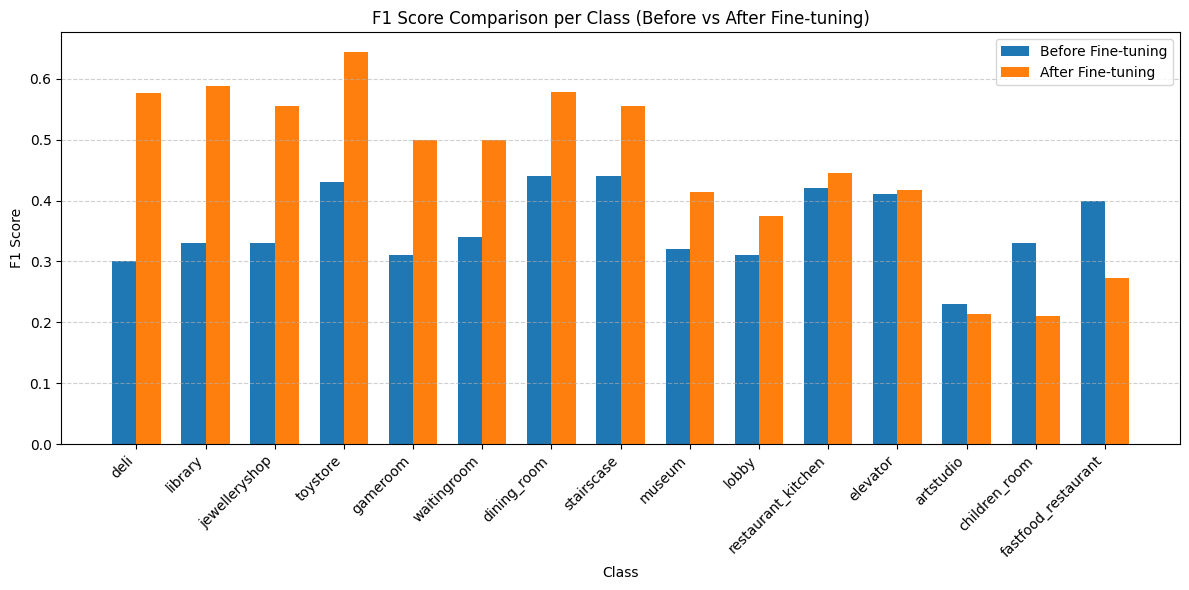

In [115]:
import matplotlib.pyplot as plt
import pandas as pd

# Make sure comparison_df is indexed by class names
# and contains 'F1-Before' and 'F1-After' columns

# Optional: Sort by F1 improvement (delta)
comparison_df["Delta"] = comparison_df["F1-After"] - comparison_df["F1-Before"]
comparison_df_sorted = comparison_df.sort_values("Delta", ascending=False)

# Plot
plt.figure(figsize=(12, 6))
bar_width = 0.35
classes = comparison_df_sorted.index
x = range(len(classes))

plt.bar(x, comparison_df_sorted["F1-Before"], width=bar_width, label="Before Fine-tuning")
plt.bar([i + bar_width for i in x], comparison_df_sorted["F1-After"], width=bar_width, label="After Fine-tuning")

plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.title("F1 Score Comparison per Class (Before vs After Fine-tuning)")
plt.xticks([i + bar_width/2 for i in x], classes, rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()
